WYBOR I ANALIZA DATASETU

In [16]:
#!pip install numpy pandas opencv-python
import hashlib
from glob import glob
import numpy as np
import pandas as pd
import cv2

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

rows = []
for c in classes:
    for p in glob(f'data/{c}/*.jpg'):
        img = cv2.imread(p)
        if img is None: #obsluga bledu imread lub to nie jest .jpg
            rows.append({'path': p, 'class': c, 'broken': True})
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)#konwertowanie na szare do liczenia jasnosci kontrastu i ostrosci
        rows.append({'path': p, 'class': c, 'broken': False, 'width': img.shape[1], 'height': img.shape[0],
                     'brightness': gray.mean(), 'contrast': gray.std(),
                     'sharpness': cv2.Laplacian(gray, cv2.CV_64F).var(),
                     'hash': hashlib.md5(open(p, 'rb').read()).hexdigest()})

df = pd.DataFrame(rows)
print(f"head : \n{df.head()}")
print(f"ilosc zdj : {len(df)}")
print(f"zepsute : {df['broken'].sum()}")
print(f"duplikaty : {df.duplicated('hash').sum()}")
print(f"klasy : \n{df['class'].value_counts()}")

head : 
                              path      class  broken  width  height  \
0    data/cardboard\cardboard1.jpg  cardboard   False    512     384   
1   data/cardboard\cardboard10.jpg  cardboard   False    512     384   
2  data/cardboard\cardboard100.jpg  cardboard   False    512     384   
3  data/cardboard\cardboard101.jpg  cardboard   False    512     384   
4  data/cardboard\cardboard102.jpg  cardboard   False    512     384   

   brightness   contrast   sharpness                              hash  
0  162.234172  31.875892   79.261693  336f2740cc7c60ac7544ad47e34dc602  
1  167.698283  38.799907  411.076231  b37669c0dcf8eb3939bb35c7be9796fb  
2  182.280197  44.498372  225.419349  fb79c3308ad68dbac1cf23c244fc0fa5  
3  130.963028  68.561937   21.528351  733b19b0875874a4804dc2b3bf7a2c08  
4  165.178823  45.320633   91.037846  eded15aa90832e6144fccb292448ef43  
ilosc zdj : 2527
zepsute : 0
duplikaty : 3
klasy : 
class
paper        594
glass        501
plastic      482
metal       

In [17]:
#wywalenie zepsutych i duplikatow
df = df[df['broken'] == False]
df = df.drop_duplicates('hash')
print(f"po czyszczeniu : {len(df)}")

print(df[['width', 'height', 'brightness', 'contrast', 'sharpness']].describe())
print(df.groupby('class')[['brightness', 'contrast', 'sharpness']].mean().round(1))

po czyszczeniu : 2524
        width  height   brightness     contrast    sharpness
count  2524.0  2524.0  2524.000000  2524.000000  2524.000000
mean    512.0   384.0   164.674676    46.374020   334.871038
std       0.0     0.0    20.005435    15.505422   438.627002
min     512.0   384.0    77.998515     7.494097     2.049306
25%     512.0   384.0   153.581912    34.923092    69.923313
50%     512.0   384.0   168.403058    45.064001   173.763745
75%     512.0   384.0   177.686162    57.465299   404.359458
max     512.0   384.0   224.416036    98.731349  4127.156033
           brightness  contrast  sharpness
class                                     
cardboard       152.8      45.5      231.0
glass           171.4      47.4      170.1
metal           158.7      54.6      380.8
paper           165.8      48.1      625.5
plastic         170.3      37.6      227.4
trash           168.0      43.7      222.1


Wszystkie maja 512x384, jasnosc dosyc wysoka pewnie przez tlo, trash ma mniej zdjec od innych klas

CZYSZCZENIE

In [18]:
#granice ustalamy wlasne ja tu wyczytalem na przyklad ze 40 to nic nie widac

df_all = df.copy()
df_all['bad'] = False
df_all.loc[df_all['brightness'] < 40, 'bad'] = True #za ciemne
df_all.loc[df_all['brightness'] > 250, 'bad'] = True #za biale
df_all.loc[df_all['sharpness'] < 20, 'bad'] = True #zbyt rozmazane
print(f"do wywalenia : {df_all['bad'].sum()}")

df = df_all[df_all['bad'] == False]
print(f"zostalo : {len(df)}")

do wywalenia : 160
zostalo : 2364


TO TE KRAWEDZIE -------- MADE IN CLAUDE ------ CLAUDIUSZ sigma mafia do poprawki

In [19]:
def get_box(img):
    h, w = img.shape[:2]
    blur = cv2.GaussianBlur(img, (9, 9), 0) #lekkie rozmycie zeby faktura tla nie dawala krawedzi
    edges = cv2.Canny(blur, 30, 100) #wykrywanie krawedzi (bialy = krawedz)
    edges = cv2.dilate(edges, np.ones((15, 15), np.uint8)) #pogrubienie krawedzi zeby polaczyly sie w jeden ksztalt
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #obrysy ksztaltow
    if len(contours) == 0: #brak krawedzi
        return 10, 10, w - 10, h - 10
    biggest = max(contours, key=cv2.contourArea) #najwiekszy ksztalt = nasz obiekt
    x, y, bw, bh = cv2.boundingRect(biggest) #prostokat wokol niego
    if bw * bh < 0.02 * w * h: #za maly = to nie obiekt
        return 10, 10, w - 10, h - 10
    return x, y, x + bw, y + bh

boxes = []
for p in df['path']:
    boxes.append(get_box(cv2.imread(p)))

df[['x1', 'y1', 'x2', 'y2']] = np.array(boxes)
df['box_area'] = (df['x2'] - df['x1']) * (df['y2'] - df['y1']) / (512 * 384) #jaka czesc zdjecia zajmuje ramka
print(f"bez ramki (cale zdjecie) : {((df['x1'] == 10) & (df['y1'] == 10)).sum()}")
print(df.groupby('class')['box_area'].describe().round(2))

bez ramki (cale zdjecie) : 11
           count  mean   std   min   25%   50%   75%   max
class                                                     
cardboard  387.0  0.49  0.32  0.02  0.20  0.45  0.77  1.00
glass      450.0  0.44  0.20  0.06  0.29  0.41  0.57  1.00
metal      402.0  0.51  0.23  0.03  0.33  0.50  0.69  1.00
paper      570.0  0.63  0.28  0.02  0.40  0.69  0.88  1.00
plastic    430.0  0.40  0.22  0.02  0.23  0.37  0.55  1.00
trash      125.0  0.40  0.20  0.08  0.23  0.37  0.54  0.94


In [20]:
"""#!pip install matplotlib
import matplotlib.pyplot as plt

big = df.sort_values('box_area', ascending=False).head(4)
plt.figure(figsize=(16, 7))
for k, i in enumerate(big.index):
    img = cv2.imread(df.loc[i, 'path'])
    bg = np.median(np.concatenate([img[:10], img[-10:]]), axis=(0, 1))
    mask = np.abs(img.astype(int) - bg).sum(axis=2) > 60 #to samo co w get_box

    cv2.rectangle(img, (int(df.loc[i, 'x1']), int(df.loc[i, 'y1'])), (int(df.loc[i, 'x2']), int(df.loc[i, 'y2'])), (0, 255, 0), 3)
    plt.subplot(2, 4, k + 1)
    plt.imshow(img[:, :, ::-1])
    plt.title(f"{df.loc[i, 'class']} {df.loc[i, 'box_area']:.2f}")
    plt.axis('off')
    plt.subplot(2, 4, k + 5)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
plt.show() """ #claudiusz na pomoc do rozwiazania tych boxow

'#!pip install matplotlib\nimport matplotlib.pyplot as plt\n\nbig = df.sort_values(\'box_area\', ascending=False).head(4)\nplt.figure(figsize=(16, 7))\nfor k, i in enumerate(big.index):\n    img = cv2.imread(df.loc[i, \'path\'])\n    bg = np.median(np.concatenate([img[:10], img[-10:]]), axis=(0, 1))\n    mask = np.abs(img.astype(int) - bg).sum(axis=2) > 60 #to samo co w get_box\n\n    cv2.rectangle(img, (int(df.loc[i, \'x1\']), int(df.loc[i, \'y1\'])), (int(df.loc[i, \'x2\']), int(df.loc[i, \'y2\'])), (0, 255, 0), 3)\n    plt.subplot(2, 4, k + 1)\n    plt.imshow(img[:, :, ::-1])\n    plt.title(f"{df.loc[i, \'class\']} {df.loc[i, \'box_area\']:.2f}")\n    plt.axis(\'off\')\n    plt.subplot(2, 4, k + 5)\n    plt.imshow(mask, cmap=\'gray\')\n    plt.axis(\'off\')\nplt.show() '

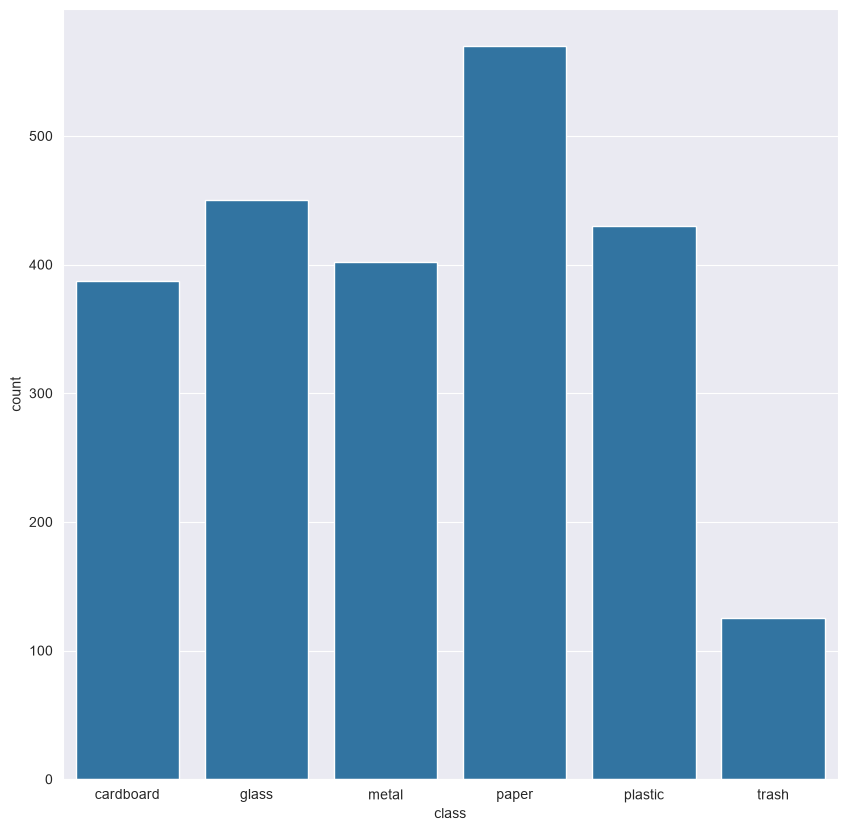

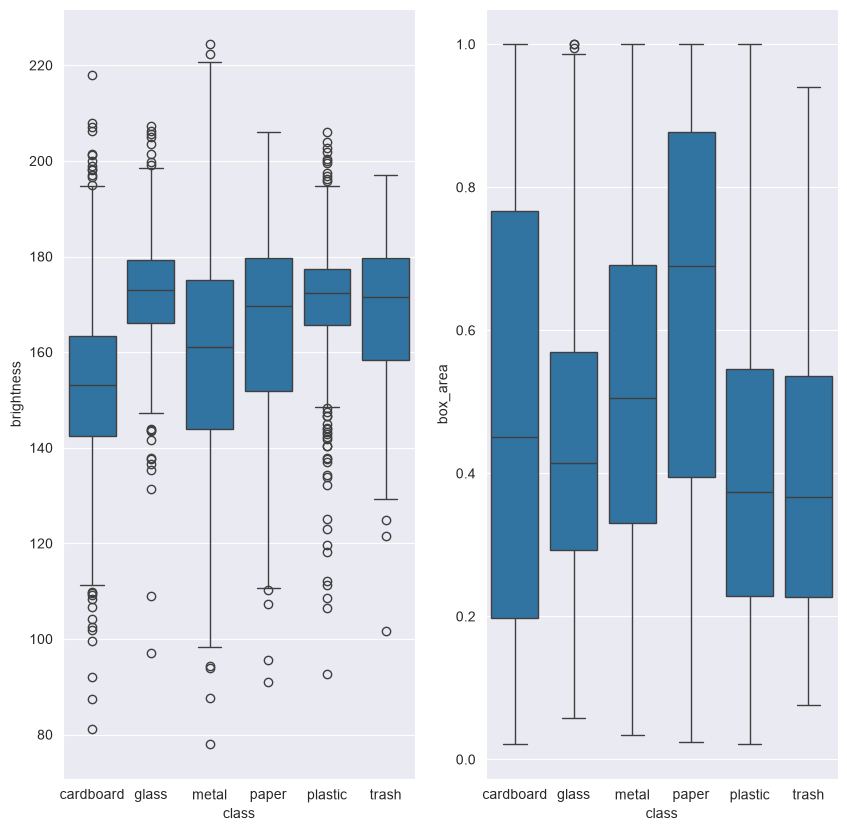

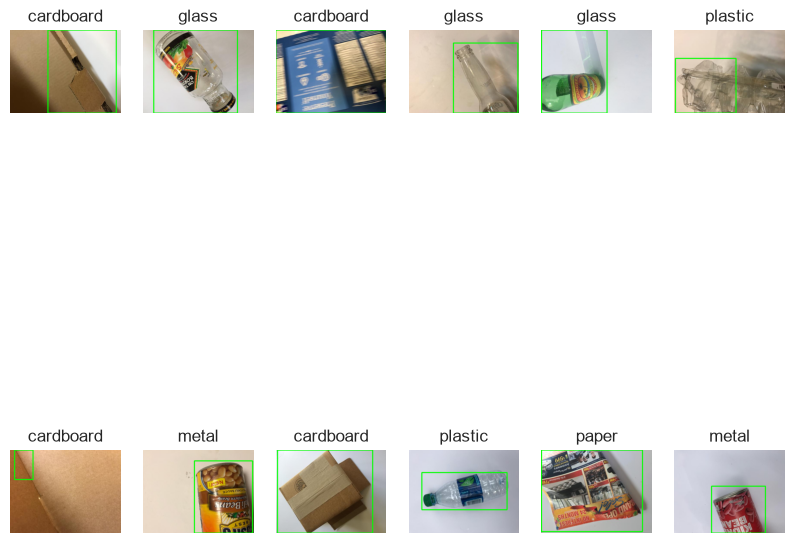

In [21]:
#!pip install matplotlib seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.countplot(data=df, x='class')
plt.show()

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='class', y='brightness')
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='class', y='box_area')
plt.show()

plt.figure(figsize=(10, 10))
for k, i in enumerate(df.sample(12, random_state=1).index):
    img = cv2.imread(df.loc[i, 'path'])
    cv2.rectangle(img, (int(df.loc[i, 'x1']), int(df.loc[i, 'y1'])), (int(df.loc[i, 'x2']), int(df.loc[i, 'y2'])), (0, 255, 0), 3)
    plt.subplot(2, 6, k + 1)
    plt.imshow(img[:, :, ::-1])
    plt.title(df.loc[i, 'class'])
    plt.axis('off')
plt.show()

Podzial train, val, test 70/15/15

In [22]:
#!pip install scikit-learn
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42) #stratify do tego samego % klas
val, test = train_test_split(temp, test_size=0.5, stratify=temp['class'], random_state=42)

df['split'] = 'train'
df.loc[val.index, 'split'] = 'val'
df.loc[test.index, 'split'] = 'test'
print(pd.crosstab(df['class'], df['split']))

split      test  train  val
class                      
cardboard    58    271   58
glass        68    315   67
metal        60    281   61
paper        86    399   85
plastic      64    301   65
trash        19     87   19


PREPROCESSING

Zapis w formacie yolo
Yolo chce zdj w folderze images/ i obok txt z ramka w folderze labels/

In [23]:
import os, shutil

if os.path.exists('yolo'):
    shutil.rmtree('yolo') #kasowanie starych plikow

for split in ['train', 'val', 'test']:
    os.makedirs(f'yolo/images/{split}')
    os.makedirs(f'yolo/labels/{split}')

for i, row in df.iterrows():
    shutil.copy(row['path'], f"yolo/images/{row['split']}/{i}.jpg") #kopiowanie zdjecia do train/split

    #ramka w formacie yolo srodek, szerokosc i wysokosc przez rozmiar
    x = (row['x1'] + row['x2']) / 2 / 512 #srodek ramki w poziomie
    y = (row['y1'] + row['y2']) / 2 / 384 #srodek ramki w pionie
    w = (row['x2'] - row['x1']) / 512 #szerokosc ramki
    h = (row['y2'] - row['y1']) / 384 #wysokosc ramki
    with open(f"yolo/labels/{row['split']}/{i}.txt", 'w') as f: #ten sam numer co zdj tylko .txt
        f.write(f"{classes.index(row['class'])} {x} {y} {w} {h}")

with open('yolo/data.yaml', 'w') as f: #plik dla yolo gdzie sa zdjecia i podzialy
    f.write(f"path: {os.path.abspath('yolo')}\ntrain: images/train\nval: images/val\ntest: images/test\nnames: {classes}")

for split in ['train', 'val', 'test']:
    print(f"{split} : {len(os.listdir(f'yolo/images/{split}'))} zdjec, {len(os.listdir(f'yolo/labels/{split}'))} ramek")

train : 1654 zdjec, 1654 ramek
val : 355 zdjec, 355 ramek
test : 355 zdjec, 355 ramek


Normalizacja - piksele /255 zeby byly 0-1.
Skalowanie do 512x512 (z zachowaniem proporcji, szare paski) i normalizacje robi yolo samo przy wczytywaniu zdjec do treningu (imgsz=512)

In [24]:
#normalizacja 0-255 na 0-1 (ponoc yolo sam to robi przy treningu)
img = cv2.imread(df['path'].iloc[0]) / 255
print(f"min : {img.min()}  max : {img.max()}")

min : 0.0  max : 0.9921568627450981
